In [36]:
# load settings
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [68]:
class PlotSettings:
    COLORS = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES = {"CHILDES": "-", "child": "-", "LSTM": "-", "trans": ":"}

    label_fontsize = 18
    linewidth = 3

    @classmethod
    def configure_plot(self, title=None, model=None):
        if title or model:
            plt.title(title or model, fontsize=18, fontweight="bold")
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.grid(True, linestyle=":", linewidth=1, color="#bbbbbb")

    @classmethod
    def configure_legend(cls):
        plt.legend(title="Settings", title_fontsize=28, fontsize=28, loc="upper left", bbox_to_anchor=(1.1, 1))

    @classmethod
    def save_figure(cls, filepath):
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

# Core metrics

In [78]:
# plot curves
df = raw_data[raw_data["temp"] == 1.0]
df = df.dropna()
# Sort by month and combine dataset + model_type for labels
df = df.sort_values("month")
df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"


def plot_curves(df, x_header: str, y_header: str, group_header: str, y_lim=[0, 1]) -> None:
    """Plot multiple curves by different groups."""
    PlotSettings.configure_plot()
    # Calculate mean and confidence intervals
    df_stats = df.groupby([group_header, x_header])[y_header].agg(["mean", "std", "count"]).reset_index()
    df_stats["ci"] = 1.96 * df_stats["std"] / np.sqrt(df_stats["count"])

    unique_conditions = df_stats["condition"].unique()
    extra_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_conditions)))
    color_dict = {cond: PlotSettings.COLORS.get(cond, extra_colors[i]) for i, cond in enumerate(unique_conditions)}

    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plt.plot(
            subset[x_header],
            subset["mean"],
            label=condition,
            color=color_dict[condition],
            linestyle=PlotSettings.LINESTYLES.get(condition.split("(")[0], "-"),
            linewidth=PlotSettings.linewidth,
        )
        plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color_dict[condition], alpha=0.2)
        plt.ylim(y_lim)
    plt.xlabel(x_header, fontsize=PlotSettings.label_fontsize)
    plt.ylabel(y_header, fontsize=PlotSettings.label_fontsize)
    PlotSettings.configure_legend()


In [79]:
class PlotSettings:
    """Class to manage plot styling and configuration."""

    COLORS: dict[str, str] = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {"CHILDES": "-", "child": "-", "LSTM": "-", "trans": "-."}

    DEFAULTS = {"label_fontsize": 18, "linewidth": 3, "title_fontsize": 28, "grid_color": "#bbbbbb"}

    @classmethod
    def configure_plot(cls, title: str = None, model: str = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=cls.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=cls.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=cls.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=cls.DEFAULTS["grid_color"])

    @classmethod
    def configure_legend(cls) -> None:
        """Configure legend settings."""
        plt.legend(title="Settings", title_fontsize=cls.DEFAULTS["title_fontsize"], fontsize=cls.DEFAULTS["title_fontsize"], loc="upper left", bbox_to_anchor=(1.1, 1))

    @classmethod
    def save_figure(cls, filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()


def calculate_statistics(df: pd.DataFrame, group_header: str, x_header: str, y_header: str) -> pd.DataFrame:
    """Calculate mean, standard deviation, and confidence intervals."""
    stats = df.groupby([group_header, x_header])[y_header].agg(["mean", "std", "count"]).reset_index()

    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def get_color_mapping(unique_conditions: list[str], plot_settings: PlotSettings) -> dict[str, str]:
    """Create color mapping for each condition."""
    extra_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_conditions)))
    return {cond: plot_settings.COLORS.get(cond, extra_colors[i]) for i, cond in enumerate(unique_conditions)}


def extract_style(text: str) -> str:
    """Extract text inside parentheses. Returns empty string if no parentheses found."""
    print(text)
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str, plot_settings: PlotSettings) -> None:
    """Plot curve for a single condition with confidence interval."""
    color_dict = plot_settings.COLORS
    plt.plot(
        subset[x_header],
        subset["mean"],
        label=condition,
        color=color_dict[condition.split("(")[0]],
        linestyle=plot_settings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=plot_settings.DEFAULTS["linewidth"],
    )
    plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color_dict[condition.split("(")[0]], alpha=0.2)


def plot_curves(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, y_lim: list[float] = [0, 1]) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    # Initial plot configuration
    PlotSettings.configure_plot()

    # Calculate statistics
    df_stats = calculate_statistics(df, group_header, x_header, y_header)
    # Get unique conditions and their color mapping
    unique_conditions = df_stats[group_header].unique()
    # Plot each condition
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header, PlotSettings)

    # Configure plot aesthetics
    plt.ylim(y_lim)
    plt.xlabel(x_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    PlotSettings.configure_legend()

CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)


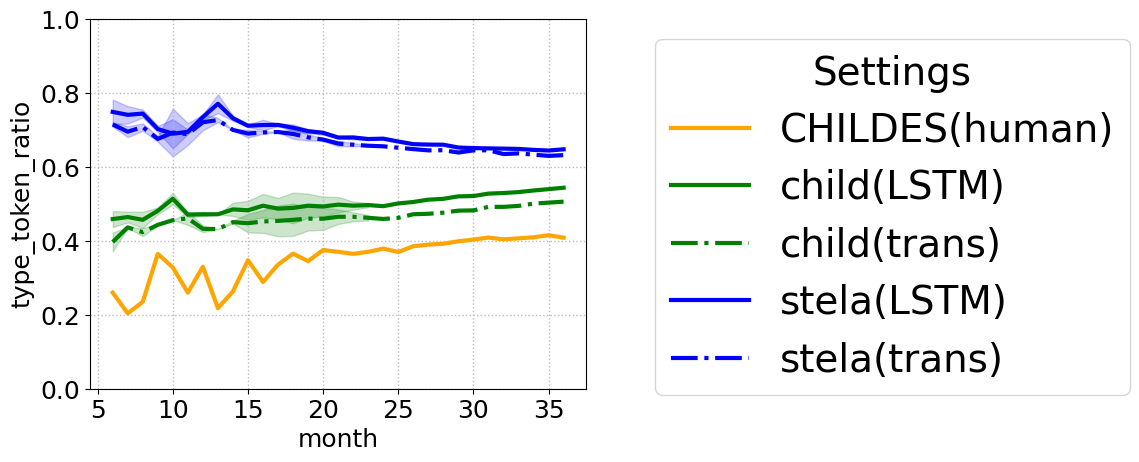

In [80]:
# Usage
x_header = "month"
y_header = "type_token_ratio"
group_header = "condition"
fig = plot_curves(df, x_header, y_header, group_header)

CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)


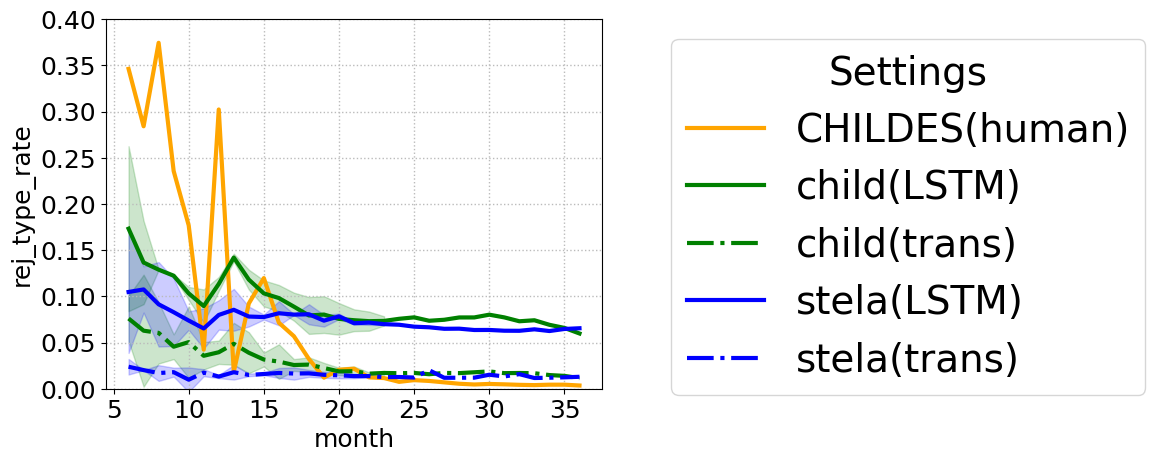

In [81]:
# Usage
x_header = "month"
y_header = "rej_type_rate"
group_header = "condition"
fig = plot_curves(df, x_header, y_header, group_header, y_lim=[0, 0.4])

# Temperature trade-off 

In [59]:
# plot out the results
def temp_tradeoff(metric: str, name: str, train_set, mean, y_lim=[0, 1]):
    for MODEL in MODEL_lst:
        frame = score_all[score_all["model"] == MODEL]
        # plot out the figures
        plt.plot(frame["CDI"], frame[metric], marker="o", linestyle="--", color=color_dict[MODEL], label=MODEL)
        # Add labels next to each dot
        for x, y, label in zip(frame["CDI"], frame[metric], frame["temp"]):
            plt.text(x, y, label, fontsize=12, ha="right", va="bottom")
    # Show legend for lines
    plt.legend()

    # plot the adult and child
    frame = score_all[score_all["model"] == "child"]
    plt.scatter(frame["CDI"], frame[metric], marker="o", linestyle="--", color=color_dict["child"], label="child")
    # Add labels next to each dot
    for x, y in zip(frame["CDI"], frame[metric]):
        plt.text(x, y, "child", fontsize=12, ha="right", va="bottom")

    # Adding labels and title
    plt.xlabel("CDI", fontsize=15)
    plt.ylabel(metric, fontsize=15)
    # Show grid for better readability (optional)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle=":", linewidth=1, color="#bbbbbb")
    plt.xlim([0, 1])
    plt.ylim(y_lim)
    # Display the plot
    plt.show()


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

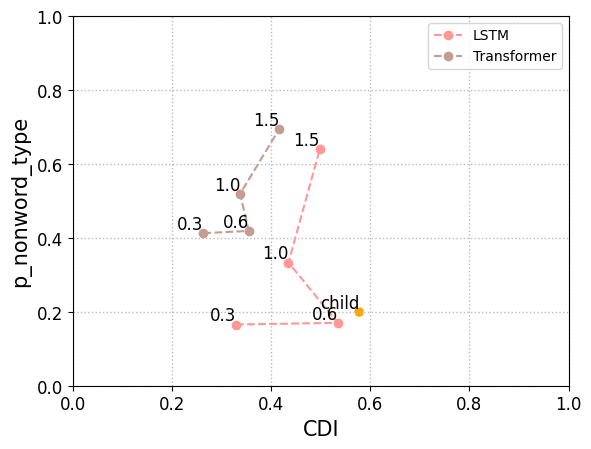

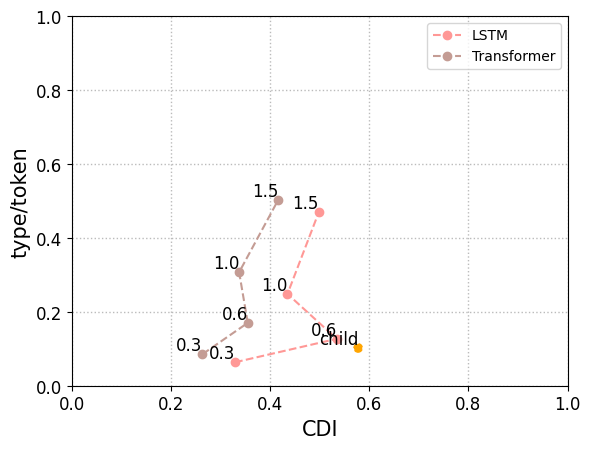

"\nmetric = 'slope'\nname = 'slope'\ntemp_tradeoff(metric,name,mean,[-25,0])\n"

In [60]:
# match the slope with CDI
mean = True
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean, train_set)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean, train_set)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

In [47]:
# match the slope with CDI
mean = False
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean, train_set)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean, train_set)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataF

TypeError: temp_tradeoff() missing 1 required positional argument: 'mean'

# Case study

## scatter plot of different vocab distr

In [114]:
def load_count(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)
    return all_count


# load data recursively
def load_files(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)

    # divide into different types of sets
    gen_count = []
    unwanted_lst = ["train", "child", "adult"]
    for tc in all_count:
        if tc.name not in unwanted_lst:
            gen_count.append(tc)
        if tc.name == "train":
            ref_count = tc
        else:
            pass
    return all_count, ref_count, gen_count

In [116]:
def line_plot(data, fig_path: str, prompt_type: str, model: str, xlog=True, ylim=[0, 1]):
    """Generic line plotting function; data is a dictionnary associating a name with a dataframe with two columns
    (the first one for x, the second one for y)
    """
    # plt.figure(figsize=(10, 5))  # Set the size of the plot

    for key in data:
        df = data[key]
        xname = df.columns[0]
        yname = df.columns[1]
        aggregated_df = df.groupby(xname)[yname].mean().reset_index()
        if key == "ind" or key == "ood":
            linetyle = "-"
            linewidth = 3.5
        else:
            linetyle = "-"
            linewidth = 3
        plt.plot(aggregated_df[xname], aggregated_df[yname], linewidth=linewidth, linestyle=linetyle, label=key, color=color_dict[key])

    plt.xlabel(xname, fontsize=20)  # Label for the x-axis
    plt.ylabel(yname, fontsize=20)  # Label for the y-axis
    plt.ylim(ylim)
    # plt.axhline(y=0, color='red', linestyle='--',linewidth=3.5, label='y = 0')
    if xlog:
        plt.xscale("log")


def tc_plot_miss_oov_rates(ref_count: TokenCount, gen_count_list: list, set_name: str, fig_path: str, prompt_type: str, model: str, groupbin=50):
    """
     Plots three curves regarding missing words and oovs

    :param ref_count: a reference TokenCount
    :param gen_count_list: a list of generated or test TokenCount
    :param groupbin:
    :return: dataframe containing different scores
    """
    pmiss = {}
    poov = {}

    for gen_count in gen_count_list:
        msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=groupbin)
        if set_name == "pmiss":
            pmiss[gen_count.name] = msc[["medcount", "pmiss"]]
            line_plot(pmiss, fig_path + "M.png", prompt_type, model)
        elif set_name == "oov":
            poov[gen_count.name] = osc[["medcount", "poov"]]
            line_plot(poov, fig_path + "O.png", prompt_type, model)
    return msc, osc, nsc

In [11]:
def scatter_hist_shade(ref_count: TokenCount, gen_count: TokenCount, model: str, ax, ax_histx, ax_histy, color_dict, num, log, bins=100, alpha_val=0.5):
    # Scatter plot with varying transparency (alpha) and edge color
    newdf = pd.merge(ref_count.df[["word", "count"]], gen_count.df[["word", "count"]], on="word", how="outer")
    newdf.set_index("word", inplace=True)
    newdf.columns = ["ref_count", "gen_count"]
    withoutoovdf = newdf[newdf["ref_count"].notna()]

    # Vary the transparency for each dataset
    ax.scatter(withoutoovdf["ref_count"], withoutoovdf["gen_count"], color=color_dict[num], alpha=alpha_val, label=f"{num}x")

    maxx = max(withoutoovdf["gen_count"])
    ax.plot([0, maxx], [0, maxx], color="r", alpha=1)

    # Plot the missing word rates by frequency
    msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=50)

    aggregated_df_miss = msc.groupby("medcount")["pmiss"].mean().reset_index()
    ax_histx.plot(aggregated_df_miss["medcount"], aggregated_df_miss["pmiss"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histx.invert_yaxis()

    aggregated_df_oov = osc.groupby("medcount")["poov"].mean().reset_index()
    ax_histy.plot(aggregated_df_oov["poov"], aggregated_df_oov["medcount"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histy.invert_xaxis()

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
        # ax_histx.set_yscale("log")
        ax_histy.set_yscale("log")
        ax_histx.set_xscale("log")
        # ax_histy.set_xscale("log")

    # Set axis range for histograms (side bars)
    ax_histx.set_ylim(0, 1)  # Set x-axis range for the top histogram
    ax_histy.set_xlim(0, 1)  # Set y-axis range for the left histogram
    # save the figure to the required directory
    plt.savefig(Path(fig_ROOT) / f"distr_{model[:5]}_{gen_count.name}.png", dpi=300, bbox_inches="tight")
    return newdf, maxx


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['correct'].fillna(newdf['ref_correct'], inplace=True)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

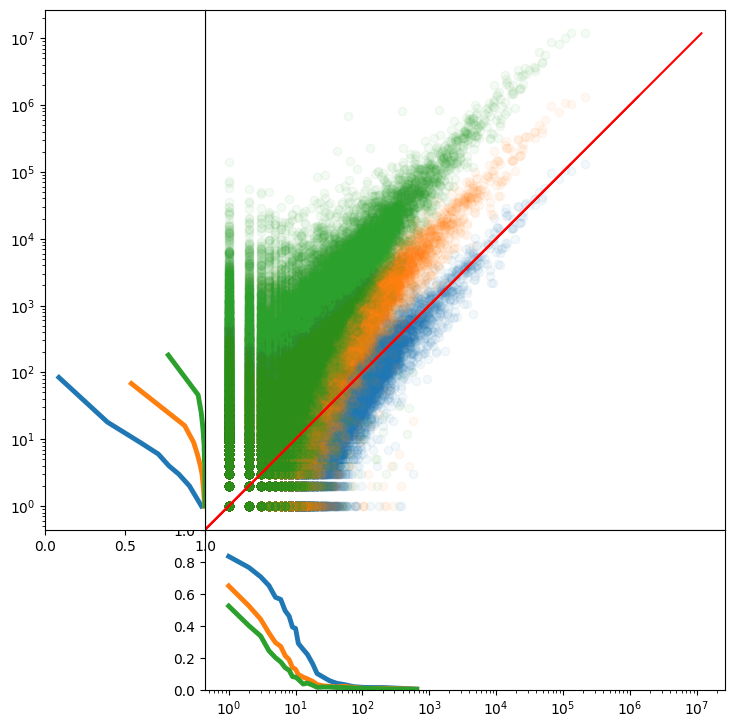

In [12]:
filename_lst = ["1", "10", "100"]
prompt_type = "unprompted"
color_dict = {
    "1": "#1f77b4",  # Blue
    "10": "#ff7f0e",  # Orange
    "100": "#2ca02c",  # Green
}

log = True
model = "LSTM"

# Create the figure once, outside the loop
fig = plt.figure(figsize=(8, 8))

# Axes locations for subplots, we will reuse them across the loop
left, width = 0.3, 0.65
bottom, height = 0.1, 0.65
spacing = 0

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom - spacing - 0.2, width, 0.2]
rect_histy = [left - spacing - 0.2, bottom, 0.2, height]

# Create ax once, and reuse for each dataset
ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

diag_lines = {}
# Loop over each dataset
for idx, filename in enumerate(filename_lst):
    freq_ROOT = f"{ROOT}/datasets/processed/freq/{prompt_type}_{model}_400_{filename}/"
    all_count, ref_count, gen_count_lst = load_files(freq_ROOT)

    # Set alpha transparency value: Start with 0.8 and reduce for each subsequent dataset
    alpha_val = 0.05
    newdf, maxx = scatter_hist_shade(ref_count, gen_count_lst[0], model, ax, ax_histx, ax_histy, color_dict, filename, log, alpha_val=alpha_val)

# Add legend and display the figure

plt.show()
